In [1]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [2]:
faces = fetch_olivetti_faces()
faces


{'data': array([[0.30991736, 0.3677686 , 0.41735536, ..., 0.15289256, 0.16115703,
         0.1570248 ],
        [0.45454547, 0.47107437, 0.5123967 , ..., 0.15289256, 0.15289256,
         0.15289256],
        [0.3181818 , 0.40082645, 0.49173555, ..., 0.14049587, 0.14876033,
         0.15289256],
        ...,
        [0.5       , 0.53305787, 0.607438  , ..., 0.17768595, 0.14876033,
         0.19008264],
        [0.21487603, 0.21900827, 0.21900827, ..., 0.57438016, 0.59090906,
         0.60330576],
        [0.5165289 , 0.46280992, 0.28099173, ..., 0.35950413, 0.3553719 ,
         0.38429752]], shape=(400, 4096), dtype=float32),
 'images': array([[[0.30991736, 0.3677686 , 0.41735536, ..., 0.37190083,
          0.3305785 , 0.30578512],
         [0.3429752 , 0.40495867, 0.43801653, ..., 0.37190083,
          0.338843  , 0.3140496 ],
         [0.3429752 , 0.41735536, 0.45041323, ..., 0.38016528,
          0.338843  , 0.29752067],
         ...,
         [0.21487603, 0.20661157, 0.2231405 , ...

In [3]:
faces['data']

array([[0.30991736, 0.3677686 , 0.41735536, ..., 0.15289256, 0.16115703,
        0.1570248 ],
       [0.45454547, 0.47107437, 0.5123967 , ..., 0.15289256, 0.15289256,
        0.15289256],
       [0.3181818 , 0.40082645, 0.49173555, ..., 0.14049587, 0.14876033,
        0.15289256],
       ...,
       [0.5       , 0.53305787, 0.607438  , ..., 0.17768595, 0.14876033,
        0.19008264],
       [0.21487603, 0.21900827, 0.21900827, ..., 0.57438016, 0.59090906,
        0.60330576],
       [0.5165289 , 0.46280992, 0.28099173, ..., 0.35950413, 0.3553719 ,
        0.38429752]], shape=(400, 4096), dtype=float32)

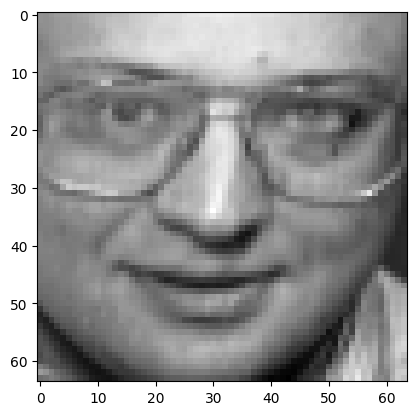

In [4]:
def mostra_imagem(x):
    img = x.reshape(64, -1, order = 'F')
    rotated = np.transpose(np.flip(img, axis = 0))
    plt.imshow(rotated, cmap='gray')
    plt.axis()
    plt.show()

mostra_imagem(faces['data'][300])

In [5]:
y = np.array( [ (i // 10) + 1 for i in range(faces['data'].shape[0]) ] )
y

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19, 19,
       19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21,
       21, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23,
       23, 23, 23, 23, 23

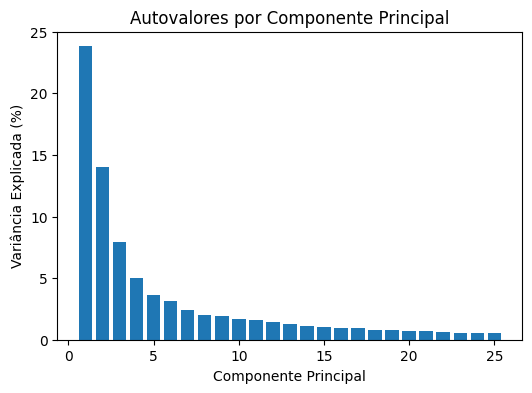

In [6]:
X = faces['data']
pca = PCA(n_components=25)
X_pca = pca.fit_transform(X)
eigenvalues = pca.explained_variance_ratio_
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(eigenvalues) + 1), eigenvalues*100)
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada (%)')
plt.title('Autovalores por Componente Principal')
plt.show()

In [7]:
eigenvalues

array([0.2381271 , 0.13993965, 0.07968616, 0.04998336, 0.03609851,
       0.03156934, 0.02426834, 0.020364  , 0.01958113, 0.01672123,
       0.01595219, 0.01436979, 0.01246742, 0.01147133, 0.01062878,
       0.0097772 , 0.0091906 , 0.00815573, 0.00753874, 0.00746984,
       0.00698576, 0.00614618, 0.00583898, 0.00569697, 0.00546162],
      dtype=float32)

In [8]:
cov = np.cov(X.T)
eigenvalues_cov, eigenvectors_cov = np.linalg.eig(cov)
eigenvalues_cov

array([ 1.88401758e+01+0.j,  1.10717621e+01+0.j,  6.30461472e+00+0.j, ...,
       -1.32701809e-17+0.j, -1.37571684e-17+0.j,  9.59268548e-18+0.j],
      shape=(4096,))

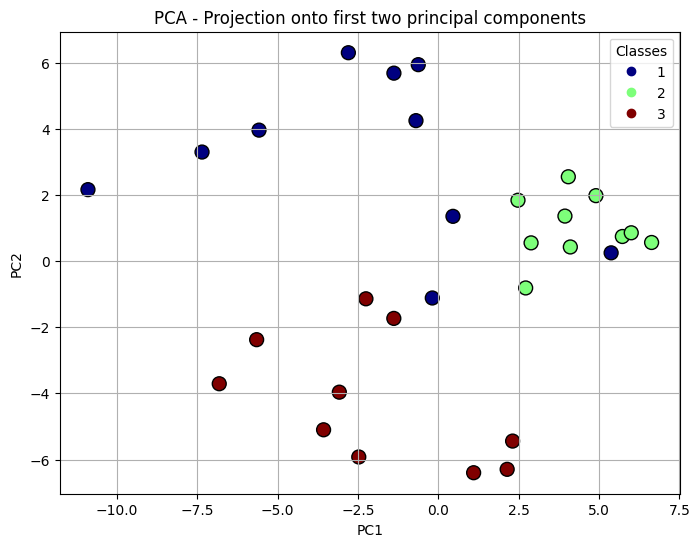

In [9]:
X30 = X[:30]
y30 = y[:30]
pca30 = PCA(n_components=2)
pca30.fit(X30)
X30_pca = pca30.transform(X30)

plt.figure(figsize=(8, 6))
plt.scatter(X30_pca[:, 0], X30_pca[:, 1], c=y30, cmap='jet', edgecolor='k', s=100)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Projection onto first two principal components')
plt.legend(*plt.gca().get_children()[0].legend_elements(), title="Classes")
plt.grid(True)
plt.show()

In [10]:
from sklearn.metrics import accuracy_score
tt_ratio = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
accuracies = {}
for ratio in tt_ratio:
    accuracies[ratio] = []
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(faces['data'], y, test_size=ratio, random_state=i, stratify=y)
        pca = PCA(n_components=10)
        pca.fit(X_train)
        X_train_pca = pca.transform(X_train)
        X_test_pca = pca.transform(X_test)
        gnb = GaussianNB()
        gnb.fit(X_train_pca, y_train)
        y_pred = gnb.predict(X_test_pca)
        accuracy = accuracy_score(y_test, y_pred)
        print(f'Test size: {ratio:.1f}, Accuracy: {accuracy:.4f}')
        accuracies[ratio].append(accuracy)
for ratio in tt_ratio:
    mean_accuracy = np.mean(accuracies[ratio])
    std_accuracy = np.std(accuracies[ratio])
    print(f'Test size: {ratio:.1f}, Mean Accuracy: {mean_accuracy:.4f}, Std Dev: {std_accuracy:.4f}')


/Users/gabri/Classes/IRP/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/Users/gabri/Classes/IRP/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/Users/gabri/Classes/IRP/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/Users/gabri/Classes/IRP/venv/lib/python3.14/site-pa

Test size: 0.1, Accuracy: 0.8750
Test size: 0.1, Accuracy: 0.8250
Test size: 0.1, Accuracy: 0.9250
Test size: 0.1, Accuracy: 0.8500
Test size: 0.1, Accuracy: 0.8000
Test size: 0.1, Accuracy: 0.7750
Test size: 0.1, Accuracy: 0.8250
Test size: 0.1, Accuracy: 0.8250
Test size: 0.1, Accuracy: 0.8500
Test size: 0.1, Accuracy: 0.7500
Test size: 0.2, Accuracy: 0.8125
Test size: 0.2, Accuracy: 0.8625
Test size: 0.2, Accuracy: 0.8625
Test size: 0.2, Accuracy: 0.8375
Test size: 0.2, Accuracy: 0.8375
Test size: 0.2, Accuracy: 0.8250
Test size: 0.2, Accuracy: 0.8250
Test size: 0.2, Accuracy: 0.7875
Test size: 0.2, Accuracy: 0.8375
Test size: 0.2, Accuracy: 0.7875
Test size: 0.3, Accuracy: 0.7583
Test size: 0.3, Accuracy: 0.8000
Test size: 0.3, Accuracy: 0.8250
Test size: 0.3, Accuracy: 0.8333
Test size: 0.3, Accuracy: 0.8083
Test size: 0.3, Accuracy: 0.8333
Test size: 0.3, Accuracy: 0.8000
Test size: 0.3, Accuracy: 0.8167
Test size: 0.3, Accuracy: 0.8000
Test size: 0.3, Accuracy: 0.7917
Test size:

In [11]:
for ratio in tt_ratio:
    mean_accuracy = np.mean(accuracies[ratio])
    std_accuracy = np.std(accuracies[ratio])
    print(f'Test size: {ratio*100}% | Mean Accuracy: {mean_accuracy:.4f} | Std Dev: {std_accuracy:.4f}')
    print('-----------------------------------------------------------')


Test size: 10.0% | Mean Accuracy: 0.8300 | Std Dev: 0.0472
-----------------------------------------------------------
Test size: 20.0% | Mean Accuracy: 0.8275 | Std Dev: 0.0249
-----------------------------------------------------------
Test size: 30.0% | Mean Accuracy: 0.8067 | Std Dev: 0.0213
-----------------------------------------------------------
Test size: 40.0% | Mean Accuracy: 0.7625 | Std Dev: 0.0379
-----------------------------------------------------------
Test size: 50.0% | Mean Accuracy: 0.7205 | Std Dev: 0.0432
-----------------------------------------------------------
Test size: 60.0% | Mean Accuracy: 0.6367 | Std Dev: 0.0427
-----------------------------------------------------------
Test size: 70.0% | Mean Accuracy: 0.5018 | Std Dev: 0.0448
-----------------------------------------------------------
Test size: 80.0% | Mean Accuracy: 0.2506 | Std Dev: 0.0461
-----------------------------------------------------------
Test size: 90.0% | Mean Accuracy: 0.4597 | Std D